In [40]:
import numpy as np
import matplotlib.pyplot as plt
import scipy 

In [41]:

def plot_psd_señal(xx, fs, N, title="Densidad Espectral de Potencia", type="scatter", xlabel="freq"):
    xx_fft = np.fft.fft(xx)
    freqs = np.fft.fftfreq(N, d=1/fs)

    psd = 2 * (1/(fs*N)) * np.abs(xx_fft)**2

    mask = freqs >= 0
    freqs = freqs[mask]
    psd = psd[mask]

    if xlabel =="k":
        freqs = np.arange(len(psd))
        xlb = "k"
    else:
        xlb = "Frecuencia (Hz)"

    figure, axs = plt.subplots(2, 1, figsize=(12, 8))
    if type == "scatter":
        axs[0].scatter(freqs, psd)
    else:
        axs[0].plot(freqs, psd)
    axs[0].set_xlabel(xlb)
    axs[0].set_ylabel('Modulo de X(k) [W]')
    axs[0].grid(True)
    axs[0].set_title(title)

    if type == "scatter":
        axs[1].scatter(freqs, 10*np.log10(psd))
    else:
        axs[1].plot(freqs, 10*np.log10(psd))
    axs[1].set_xlabel(xlb)
    axs[1].set_ylabel('Modulo de X[k] [dB]')
    axs[1].grid(True)
    axs[1].set_title("Señal en dB")

    figure.tight_layout()
    plt.show()

    return psd, freqs

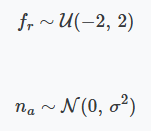

In [42]:
N = 1000
fs = 1000
realizaciones = 200

fr = np.random.uniform(-2, 2, realizaciones)

def pds_awgn(N, fs, potencia_W):
    tt = np.arange(start = 0, step = 1/fs, stop = N*(1/fs))
    desvio_std = np.sqrt(potencia_W)
    media = 0
    xx = np.random.normal(loc=media, scale=desvio_std, size=N)
    return xx, tt

pot_ruido_db = -10
na, _ = pds_awgn(N, fs=1000, potencia_W=10**(pot_ruido_db/10))

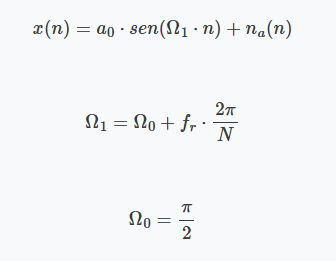

In [43]:
Omega0 = np.pi / 2
Omega1 = Omega0 + fr * (2*np.pi/N)
Omega1 = Omega1.reshape((realizaciones,1))

ang =  Omega1 * np.arange(N).reshape((1,N))
x = np.sqrt(2) *np.sin(ang) + na

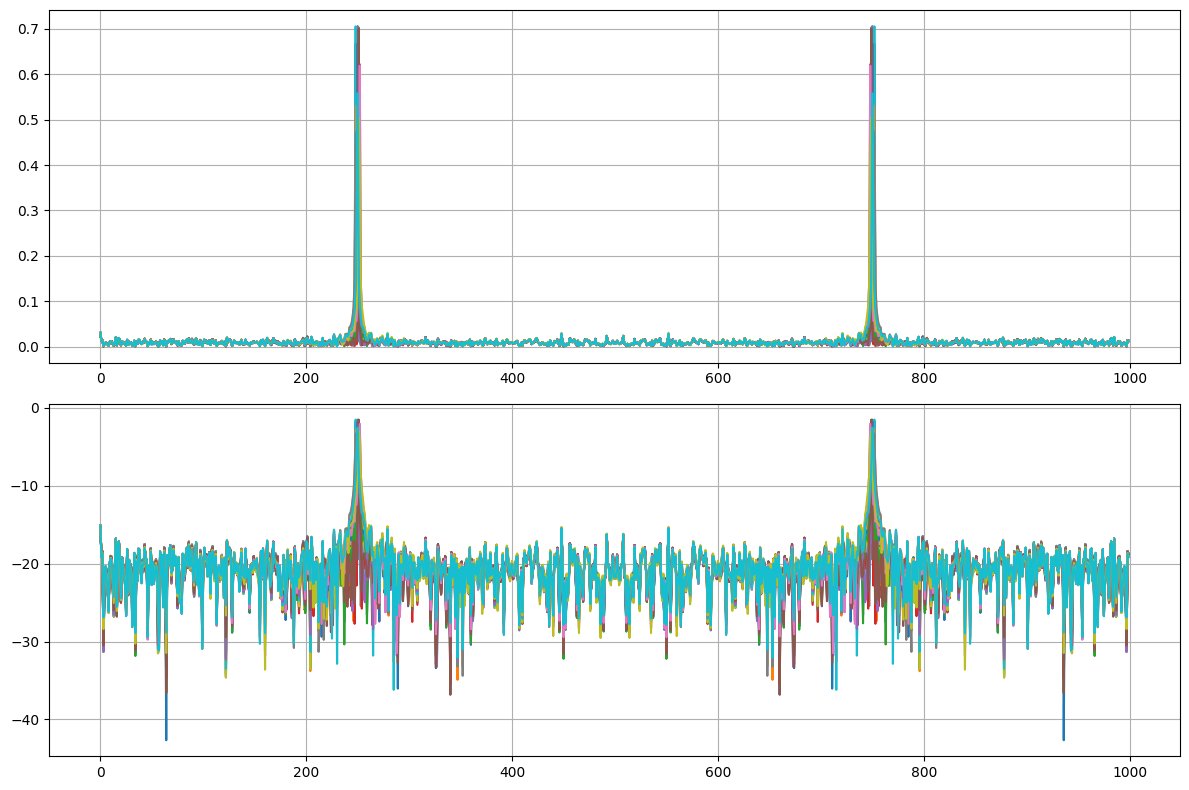

In [44]:
x_fft = np.fft.fft(x, axis=1)
x_fft_abs = np.abs(x_fft)/N

if True:
    figure, axs = plt.subplots(2, 1, figsize=(12, 8))
    for i in range(0, 20):
        axs[0].plot(x_fft_abs[i,:])
    axs[0].grid(True)

    for i in range(0, 20):
        axs[1].plot(10*np.log10(x_fft_abs[i,:]))
    axs[1].grid(True)
    figure.tight_layout()
    plt.show()

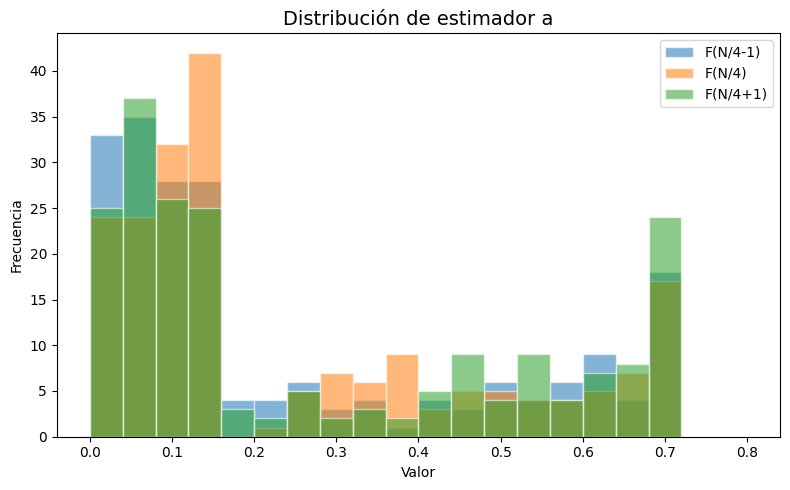

Media del estimador: 0.25186740583094347
Varianza del estimador: 0.05166932540226983


In [45]:
estimador_a_1 = (x_fft_abs[:,int(N/4-1)])
estimador_a = (x_fft_abs[:,int(N/4)])
estimador_a1 = (x_fft_abs[:,int(N/4+1)])
plt.figure(figsize=(8, 5))
plt.hist(estimador_a_1, label="F(N/4-1)", bins=20, edgecolor='white', alpha=0.55, range=(0, .8))
plt.hist(estimador_a, label="F(N/4)",bins = 20, edgecolor='white', alpha=0.55, range=(0, .8))
plt.hist(estimador_a1, label="F(N/4+1)", bins=20, edgecolor='white', alpha=0.55, range=(0, .8))
plt.title('Distribución de estimador a', fontsize=14)
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.legend()
plt.show()


print(f"Media del estimador: {np.mean(estimador_a)}")
print(f"Varianza del estimador: {np.var(estimador_a)}")

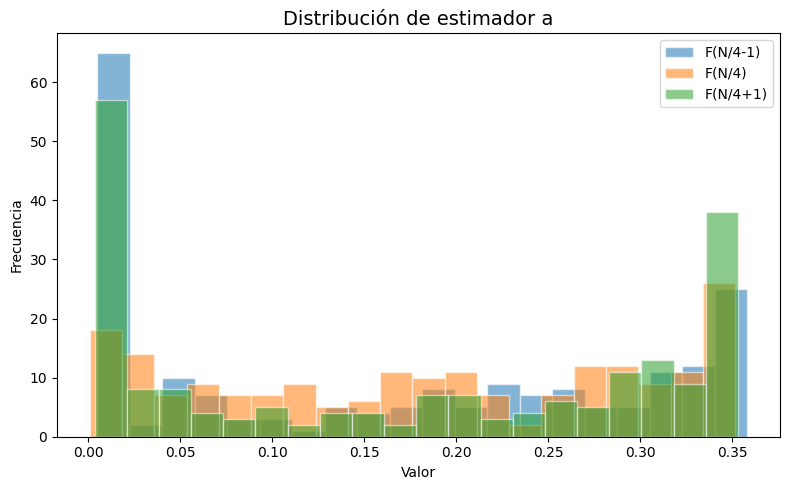

Media del estimador: 0.18501991313675206
Varianza del estimador: 0.01363020588643602


In [49]:
flattop = scipy.signal.windows.hann(N)
x_flattop = x * flattop

x_fft_ft = np.fft.fft(x_flattop, axis=1)
x_fft_ft_abs = np.abs(x_fft_ft)/N

estimador_a_1 = (x_fft_ft_abs[:,int(N/4-1)])
estimador_a = (x_fft_ft_abs[:,int(N/4)])
estimador_a1 = (x_fft_ft_abs[:,int(N/4+1)])
plt.figure(figsize=(8, 5))
plt.hist(estimador_a_1, label="F(N/4-1)", bins=20, edgecolor='white', alpha=0.55)
plt.hist(estimador_a, label="F(N/4)",bins = 20, edgecolor='white', alpha=0.55)
plt.hist(estimador_a1, label="F(N/4+1)", bins=20, edgecolor='white', alpha=0.55)
plt.title('Distribución de estimador a', fontsize=14)
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.legend()
plt.show()


print(f"Media del estimador: {np.mean(estimador_a)}")
print(f"Varianza del estimador: {np.var(estimador_a)}")